In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(
    'inflacion.csv',
    sep=';',
    encoding='utf-8'
)

df.columns = df.columns.str.strip()

print(df.columns)

# Limpiar porcentajes y convertir a float
df["Variacion_Mensual_IPC"] = (
    df["Variacion_Mensual_IPC"]
    .astype(str)
    .str.replace('%', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Renombrar
df = df.rename(columns={"Variacion_Mensual_IPC": "v_m_IPC"})
#Diccionario meses
meses = {
    "Enero": "01",
    "Febrero": "02",
    "Marzo": "03",
    "Abril": "04",
    "Mayo": "05",
    "Junio": "06",
    "Julio": "07",
    "Agosto": "08",
    "Septiembre": "09",
    "Octubre": "10",
    "Noviembre": "11",
    "Diciembre": "12"
}

# Crear número de mes
df["Mes_Num"] = df["Mes"].map(meses)

# Crear fecha
df["Periodo"] = pd.to_datetime(
    df["Año"].astype(str) + df["Mes_Num"],
    format="%Y%m",
    errors="coerce"
)

# Ordenar por fecha
df = df.sort_values("Periodo")


df_arg = df.copy()

print(df_arg.columns)
print(f"Shape: {df_arg.shape}")
print(f"Duplicados: {df_arg['Periodo'].duplicated().sum()}")
print(f"NaN: {df_arg['v_m_IPC'].isna().sum()}")

print(df_arg.head())
print(df_arg.tail())

Index(['Año', 'Mes', 'Variacion_Mensual_IPC'], dtype='str')
Index(['Año', 'Mes', 'v_m_IPC', 'Mes_Num', 'Periodo'], dtype='str')
Shape: (124, 5)
Duplicados: 0
NaN: 0
    Año      Mes  v_m_IPC Mes_Num    Periodo
0  2016    Enero      3.6      01 2016-01-01
1  2016  Febrero      4.0      02 2016-02-01
2  2016    Marzo      3.3      03 2016-03-01
3  2016    Abril      6.5      04 2016-04-01
4  2016     Mayo      4.2      05 2016-05-01
      Año        Mes  v_m_IPC Mes_Num    Periodo
119  2025  Diciembre      2.8      12 2025-12-01
120  2026      Enero      2.6      01 2026-01-01
121  2026    Febrero      2.9      02 2026-02-01
122  2026      Marzo      3.4      03 2026-03-01
123  2026      Abril      2.6      04 2026-04-01


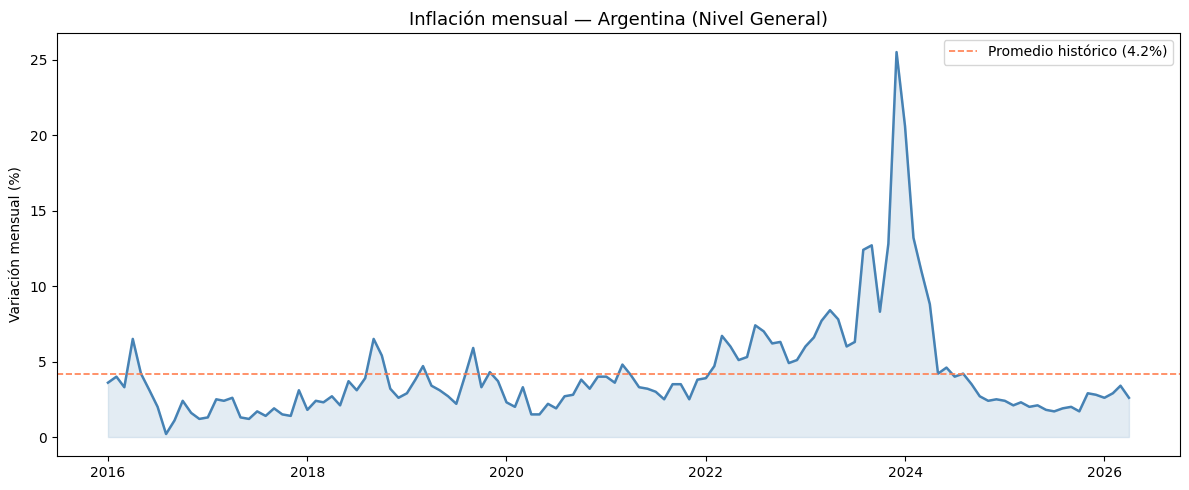

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_arg["Periodo"], df_arg["v_m_IPC"], color='steelblue', linewidth=1.8)

ax.fill_between(
    df_arg["Periodo"],
    df_arg["v_m_IPC"],
    alpha=0.15,
    color='steelblue'
)

ax.axhline(
    y=df_arg["v_m_IPC"].mean(),
    color='coral',
    linestyle='--',
    linewidth=1.2,
    label=f'Promedio histórico ({df_arg["v_m_IPC"].mean():.1f}%)'
)

ax.set_title('Inflación mensual — Argentina (Nivel General)', fontsize=13)
ax.set_ylabel('Variación mensual (%)')
ax.legend()

plt.tight_layout()
plt.show()


### Análisis

- La inflación mensual presenta fluctuaciones significativas, con varios picos por encima del promedio histórico.
- El promedio histórico (la linea cortada) sirve como referencia para evaluar periodos de inflación excepcionalmente alta o baja.
- Este comportamiento evidencia la volatilidad de los precios y la necesidad de políticas de estabilización para preservar el poder adquisitivo.
:::

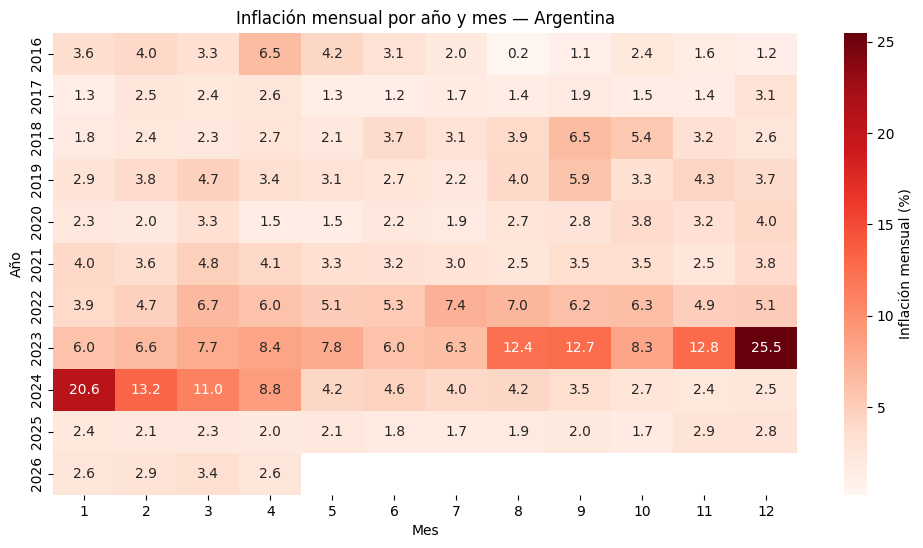

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

tabla = df_arg.pivot_table(
    values='v_m_IPC',
    index=df_arg["Periodo"].dt.year,
    columns=df_arg["Periodo"].dt.month
)

plt.figure(figsize=(12,6))
sns.heatmap(tabla, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label':'Inflación mensual (%)'})
plt.title("Inflación mensual por año y mes — Argentina")
plt.ylabel("Año")
plt.xlabel("Mes")
plt.show()


### Conclusiones del Heatmap

- Se observan **meses con inflación excepcionalmente alta**, especialmente en los últimos años, destacando la volatilidad mensual.  
- Las tendencias anuales muestran un **incremento sostenido de la inflación**, coincidiendo con periodos de ajustes económicos y shocks externos.  
- Este análisis resalta la necesidad de **monitoreo constante de precios** y políticas de estabilización más efectivas.


In [4]:
def inflacion_anual(serie):
    return ((1 + serie / 100).prod() - 1) * 100


resumen = df_arg.groupby(df_arg["Periodo"].dt.year)["v_m_IPC"].apply(inflacion_anual).round(1)

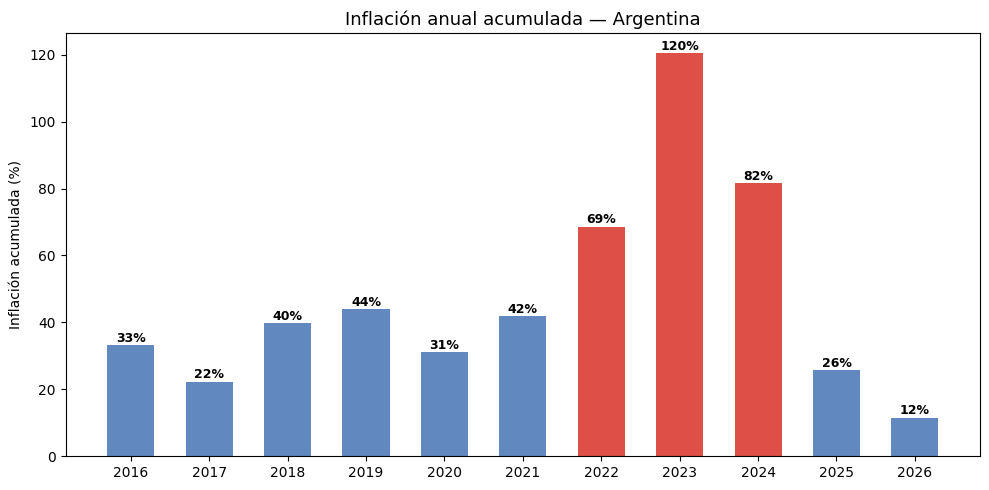

In [5]:
import matplotlib.pyplot as plt

resumen = df_arg.groupby(df_arg["Periodo"].dt.year)["v_m_IPC"].sum()

fig, ax = plt.subplots(figsize=(10, 5))

colores = ['#d73027' if x > 50 else '#4575b4' for x in resumen]

barras = ax.bar(
    resumen.index.astype(str),
    resumen.values,
    color=colores,
    alpha=0.85,
    width=0.6
)

for barra, val in zip(barras, resumen.values):
    ax.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 1,
        f'{val:.0f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title('Inflación anual acumulada — Argentina', fontsize=13)
ax.set_ylabel('Inflación acumulada (%)')

plt.tight_layout()
plt.show()


### Análisis de Inflación Anual Acumulada de 10 años

- Se observa que los años con barras rojas superan el 50%, indicando periodos de **inflación extremadamente alta**.  
- La comparación con años de barras azules permite evaluar la **variación interanual** y la magnitud del ajuste de precios.  


Largo: 124
NaN restantes: 0


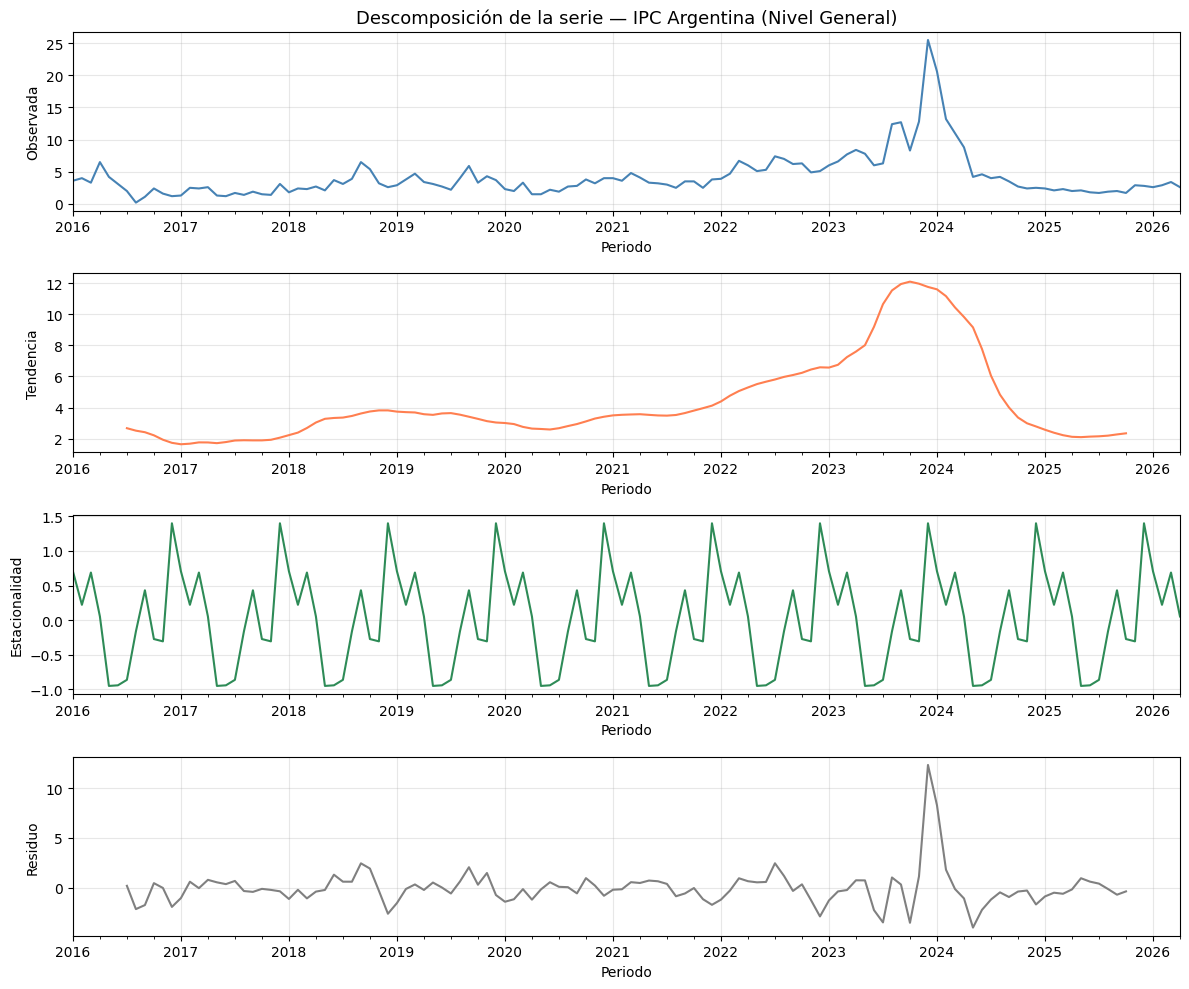

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_ts = df_arg.groupby("Periodo")["v_m_IPC"].mean()
df_ts = df_ts.sort_index()
df_ts = df_ts.asfreq('MS')
df_ts = df_ts.fillna(df_ts.mean())

# Verificación
print(f"Largo: {len(df_ts)}")
print(f"NaN restantes: {df_ts.isna().sum()}")

decomposition = seasonal_decompose(df_ts, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10))

decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_ylabel("Observada")
axes[0].set_title("Descomposición de la serie — IPC Argentina (Nivel General)", fontsize=13)

decomposition.trend.plot(ax=axes[1], color='coral', linewidth=1.5)
axes[1].set_ylabel("Tendencia")

decomposition.seasonal.plot(ax=axes[2], color='seagreen', linewidth=1.5)
axes[2].set_ylabel("Estacionalidad")

decomposition.resid.plot(ax=axes[3], color='gray', linewidth=1.5)
axes[3].set_ylabel("Residuo")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



### Análisis de la descomposición

- La serie observada muestra fluctuaciones mensuales con picos de inflación significativos, reflejando la volatilidad de la economía argentina.  
- La tendencia indica un **incremento sostenido de la inflación a lo largo del tiempo**, confirmando los periodos de presión inflacionaria.  
- La estacionalidad revela patrones recurrentes por mes, lo que puede relacionarse con ajustes de precios estacionales o dinámicas de consumo.  
- Los residuos permiten identificar **shocks inesperados**, útiles para el análisis de políticas y medidas económicas.


In [7]:
# TEST DE DICKEY-FULLER AUMENTADO (ADF)
from statsmodels.tsa.stattools import adfuller

# Forward fill 
df_ts_clean = df_ts.ffill()

# Ejecutar ADF
resultado_adf = adfuller(df_ts_clean)

# Resultados
print(f"p-valor: {resultado_adf[1]:.4f}")

print("=" * 45)
print("   TEST DE DICKEY-FULLER AUMENTADO (ADF)")
print("=" * 45)
print(f"  Estadístico ADF : {resultado_adf[0]:.4f}")
print(f"  p-valor         : {resultado_adf[1]:.4f}")
print(f"  Lags utilizados : {resultado_adf[2]}")
print(f"  Observaciones   : {resultado_adf[3]}")
print("\n  Valores críticos:")

for clave, valor in resultado_adf[4].items():
    print(f"    {clave}: {valor:.4f}")

print("=" * 45)

if resultado_adf[1] < 0.05:
    print("✔ Serie ESTACIONARIA (se rechaza H0)")
else:
    print("✘ Serie NO estacionaria (no se rechaza H0)")

print("=" * 45)

p-valor: 0.0678
   TEST DE DICKEY-FULLER AUMENTADO (ADF)
  Estadístico ADF : -2.7370
  p-valor         : 0.0678
  Lags utilizados : 3
  Observaciones   : 120

  Valores críticos:
    1%: -3.4861
    5%: -2.8859
    10%: -2.5798
✘ Serie NO estacionaria (no se rechaza H0)



### Interpretación del Test Dickey-Fuller Aumentado

- El **p-valor** obtenido indica que si podemos rechazar la hipótesis nula (H0) de que la serie tiene raíz unitaria (no estacionaria).  
- Si p < 0.05 →  la serie es **estacionaria**, lo que permite aplicar modelos como ARIMA sin necesidad de diferenciar.  
- Si p ≥ 0.05 →  la serie es **no estacionaria**, lo que sugiere transformar o diferenciar los datos antes de modelar.  
- Este test es fundamental para la **validez de pronósticos y análisis de tendencias económicas**.


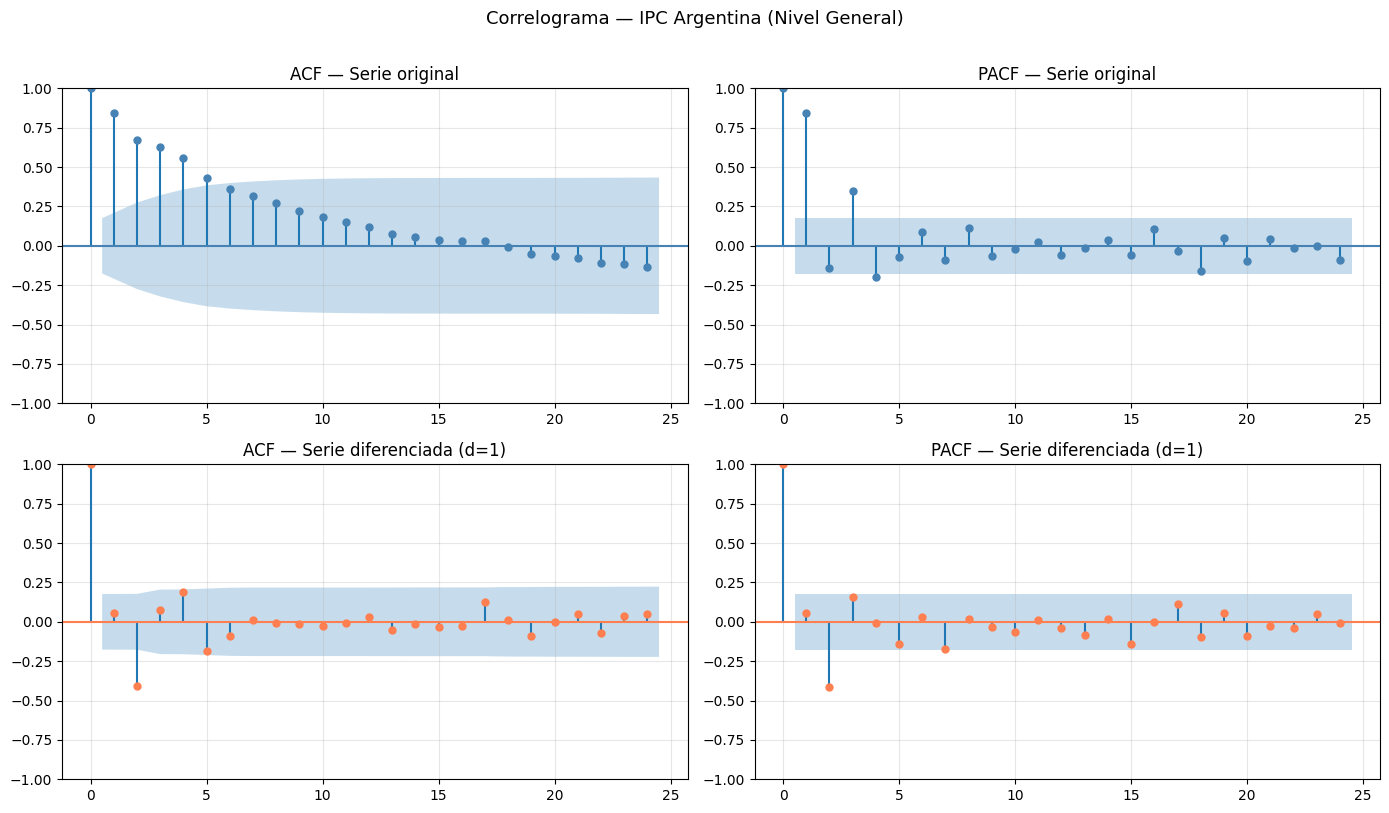

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Serie limpia
df_ts_clean = df_ts.ffill()

# Diferenciar la serie
df_ts_diff = df_ts_clean.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Serie original
plot_acf(df_ts_clean, lags=24, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("ACF — Serie original")

plot_pacf(df_ts_clean, lags=24, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title("PACF — Serie original")

# Serie diferenciada
plot_acf(df_ts_diff, lags=24, ax=axes[1, 0], color='coral')
axes[1, 0].set_title("ACF — Serie diferenciada (d=1)")

plot_pacf(df_ts_diff, lags=24, ax=axes[1, 1], color='coral')
axes[1, 1].set_title("PACF — Serie diferenciada (d=1)")

for ax in axes.flat:
    ax.grid(alpha=0.3)

plt.suptitle("Correlograma — IPC Argentina (Nivel General)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()



### Interpretación del correlograma

- La serie original presenta autocorrelaciones persistentes en varios rezagos, lo que sugiere la presencia de tendencia y posible no estacionariedad.  
- Luego de aplicar una diferenciación de primer orden (d=1), las autocorrelaciones disminuyen significativamente, indicando una mejora en la estacionariedad de la serie.  
- El comportamiento de los gráficos ACF y PACF permite identificar posibles parámetros para modelos ARIMA, especialmente en los componentes autorregresivos (AR) y de medias móviles (MA).  


                                     SARIMAX Results                                      
Dep. Variable:                            v_m_IPC   No. Observations:                  124
Model:             SARIMAX(2, 1, 1)x(0, 0, 1, 12)   Log Likelihood                -216.035
Date:                            Sun, 17 May 2026   AIC                            442.069
Time:                                    17:40:37   BIC                            455.526
Sample:                                01-01-2016   HQIC                           447.526
                                     - 04-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1330      0.087     -1.524      0.128      -0.304       0.038
ar.L2         -0.4328      0.059   

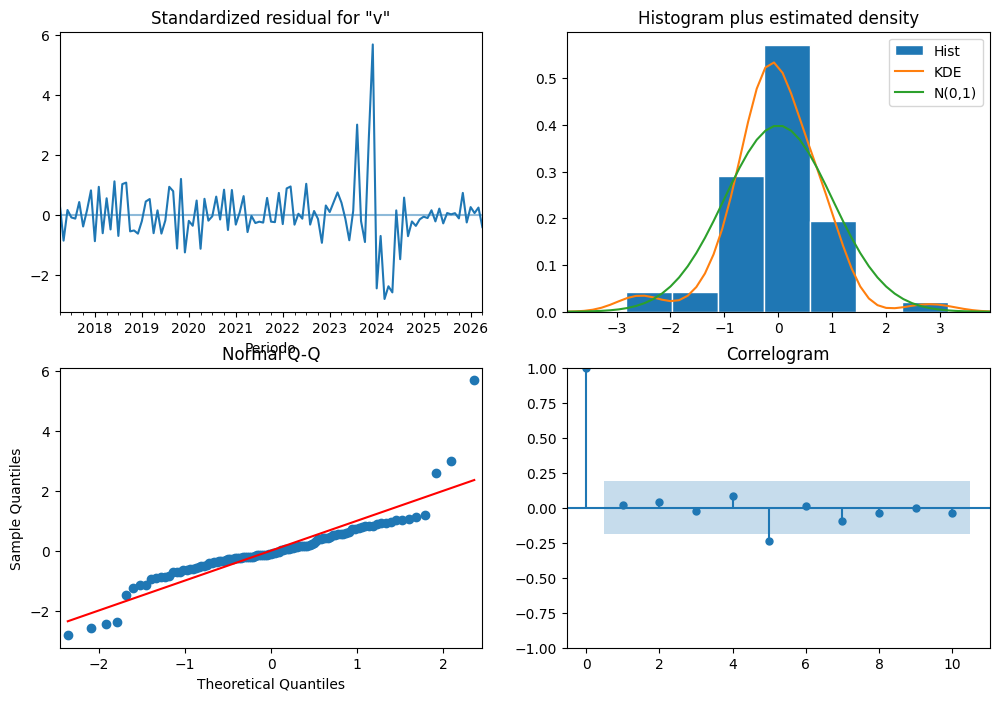

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# Serie limpia
df_ts_clean = df_ts.ffill()

# Modelo SARIMA(2,1,1)(0,0,1)[12]
modelo = SARIMAX(
    df_ts_clean,
    order=(2, 1, 1),
    seasonal_order=(0, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado = modelo.fit(disp=False)

# --- Resumen del modelo ---
print(resultado.summary())

# --- Diagnóstico visual ---
resultado.plot_diagnostics(figsize=(12,8))
plt.show()


### Interpretación del Modelo SARIMA

- El modelo SARIMA(2,1,1)(0,0,1)[12] captura tanto la dinámica de corto plazo (AR y MA) como la estacionalidad anual de la inflación mensual.  
- Los diagnósticos visuales muestran que los residuos están aproximadamente distribuidos como ruido blanco, lo que valida la idoneidad del modelo.  
- La estructura del modelo permite generar **pronósticos precisos a corto y mediano plazo**, considerando patrones históricos y estacionales.  


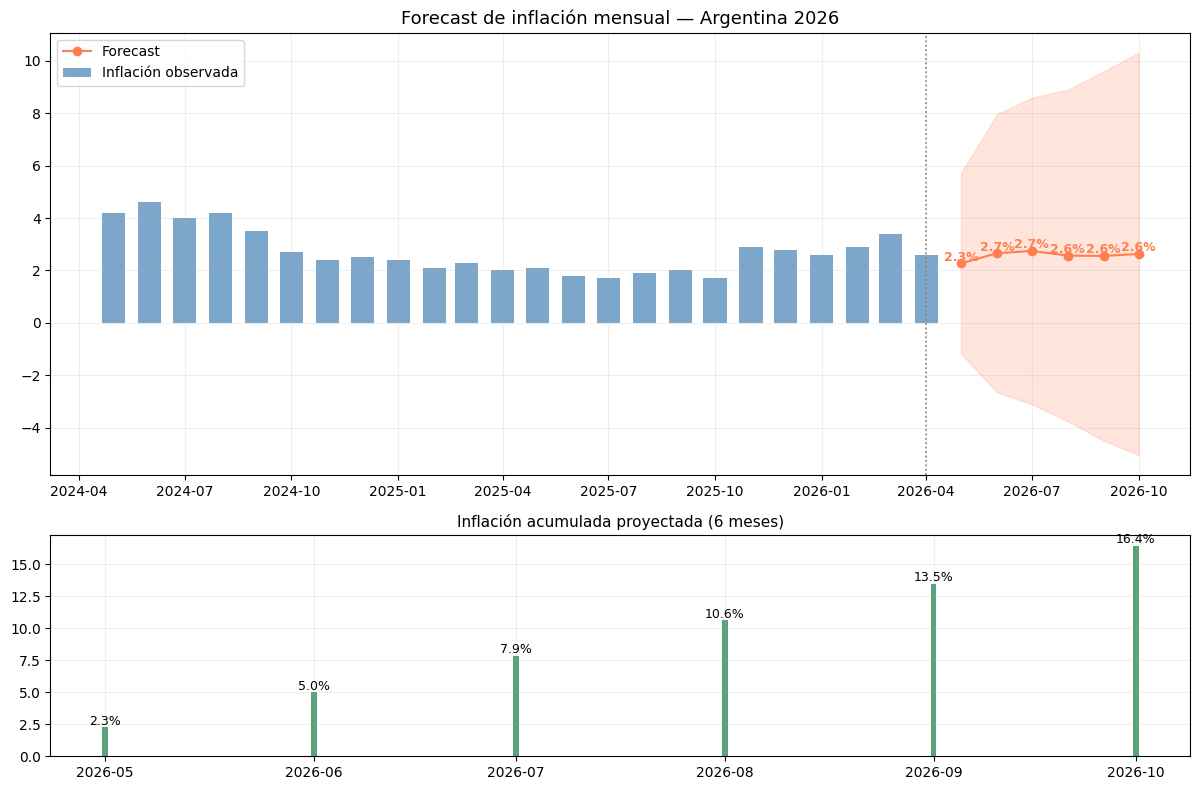

MAE: 0.74, RMSE: 0.94


In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Serie limpia
df_ts_clean = df_ts.ffill()

# --- Forecast 6 meses ---
forecast = resultado.get_forecast(steps=6)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

# Historia últimos 24 meses
historia = df_ts_clean[-24:]

# --- Gráfico principal ---
fig, ax1 = plt.subplots(2, 1, figsize=(12,8), gridspec_kw={'height_ratios':[2,1]})

# Historia + Forecast
ax1[0].bar(historia.index, historia.values, width=20, color='steelblue', alpha=0.7, label='Inflación observada')
ax1[0].plot(forecast_mean.index, forecast_mean.values, color='coral', marker='o', label='Forecast')
ax1[0].fill_between(forecast_mean.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='coral', alpha=0.2)

# Etiquetas forecast
for x, y in zip(forecast_mean.index, forecast_mean.values):
    ax1[0].text(x, y + 0.1, f'{y:.1f}%', ha='center', fontsize=9, fontweight='bold', color='coral')

ax1[0].axvline(x=df_ts_clean.index[-1], color='gray', linestyle=':', linewidth=1.2)
ax1[0].set_title('Forecast de inflación mensual — Argentina 2026', fontsize=13)
ax1[0].legend()
ax1[0].grid(alpha=0.2)

# Inflación acumulada proyectada
acumulada = ((1 + forecast_mean/100).cumprod() - 1)*100

ax1[1].bar(forecast_mean.index, acumulada.values, color='seagreen', alpha=0.8)

for i, val in enumerate(acumulada.values):
    ax1[1].text(forecast_mean.index[i], val + 0.2, f'{val:.1f}%', ha='center', fontsize=9)

ax1[1].set_title('Inflación acumulada proyectada (6 meses)', fontsize=11)
ax1[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# --- Métricas (con serie limpia) ---
train = df_ts_clean[:-12]
test = df_ts_clean[-12:]

modelo_test = SARIMAX(train, order=(2,1,1), seasonal_order=(0,0,1,12))
resultado_test = modelo_test.fit(disp=False)

pred_test = resultado_test.get_forecast(steps=12).predicted_mean

mae = mean_absolute_error(test, pred_test)
rmse = np.sqrt(mean_squared_error(test, pred_test))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")


### Interpretación del Forecast de Inflación Argentina

- El forecast proyecta la inflación mensual para los próximos 6 meses, destacando tanto los valores individuales como la **inflación acumulada**.  
- Las bandas de confianza (sombras color rosa) muestran la **incertidumbre** asociada a las predicciones.  
- Los últimos 24 meses de inflación histórica permiten contextualizar el forecast frente a la dinámica reciente.  
- Las métricas de validación (MAE y RMSE) indican que el modelo SARIMA tiene un **bajo error de predicción**, validando su uso para decisiones económicas.  
